In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [1]:
# ! pip install -q roboflow ultralytics supervision ipywidgets 

In [2]:
from roboflow import Roboflow
from ultralytics import YOLO
from IPython.display import Image
import cv2
import datetime
import supervision as sv 

In [3]:
# Download the dataset

rf = Roboflow(api_key="z1uD0b9XOZdnivUdFkEd")
project = rf.workspace("rjm-consulting").project("38-potholes")
version = project.version(2)
dataset = version.download("yolov11") # yolo26


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to 38---Potholes-2 in yolov11:: 100%|█████████████████████████████████████████████████████| 128/128 [00:00<00:00, 387.20it/s]


In [9]:
# Verify the data.yaml file
# Edit the yaml file if needed.

In [4]:
# Basic training
# Requires a T4 GPU
model = YOLO ("yolo11n.pt") # "yolo26s.pt" 

In [ ]:
dataset.location 

In [ ]:
results = model.train (data = f"{dataset.location}/data.yaml", epochs = 100) 

In [ ]:
# Download the best.pt weights to your laptop

In [ ]:
# Advanced training (Colab Pro is required)
# Requires an A100 GPU
model = YOLO ("yolo26x.pt") # "yolo26x.yaml"
results = model.train (data = f"{dataset.location}/data.yaml", epochs = 100)

In [ ]:
# Download the best.pt weights to your laptop

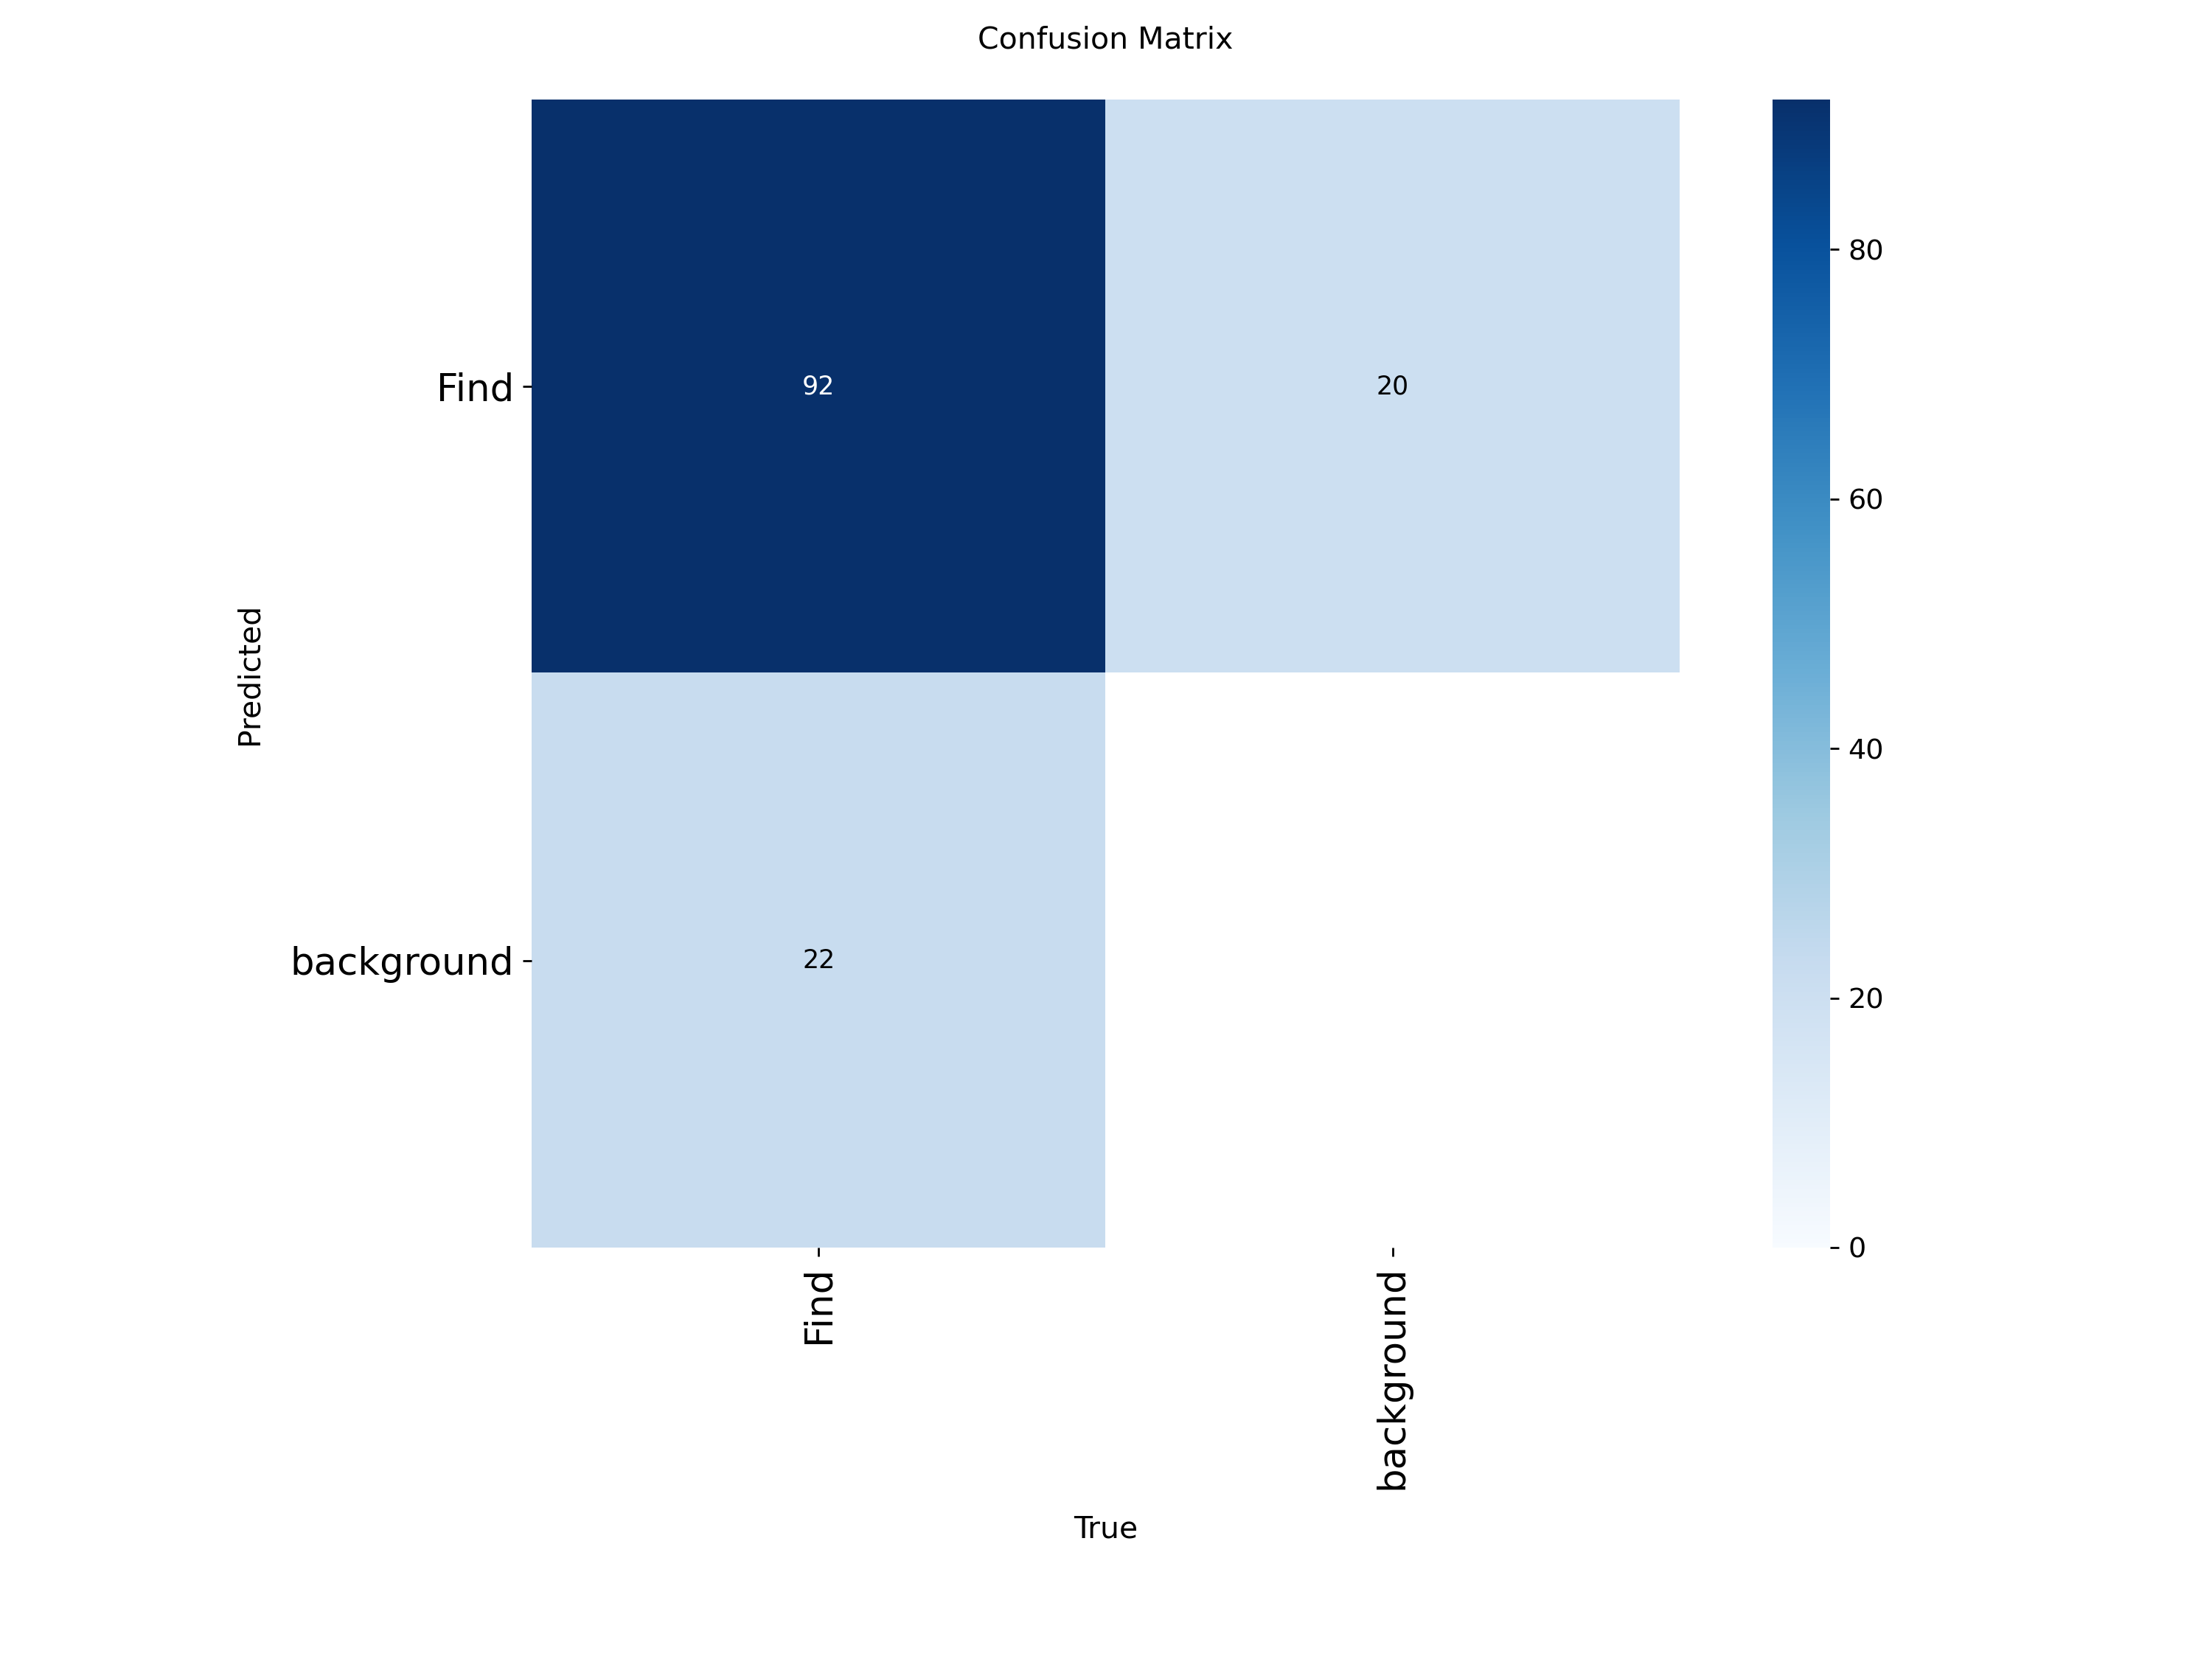

In [7]:
# Display the results
Image (filename=f"/content/runs/detect/train/confusion_matrix.png", width=600)

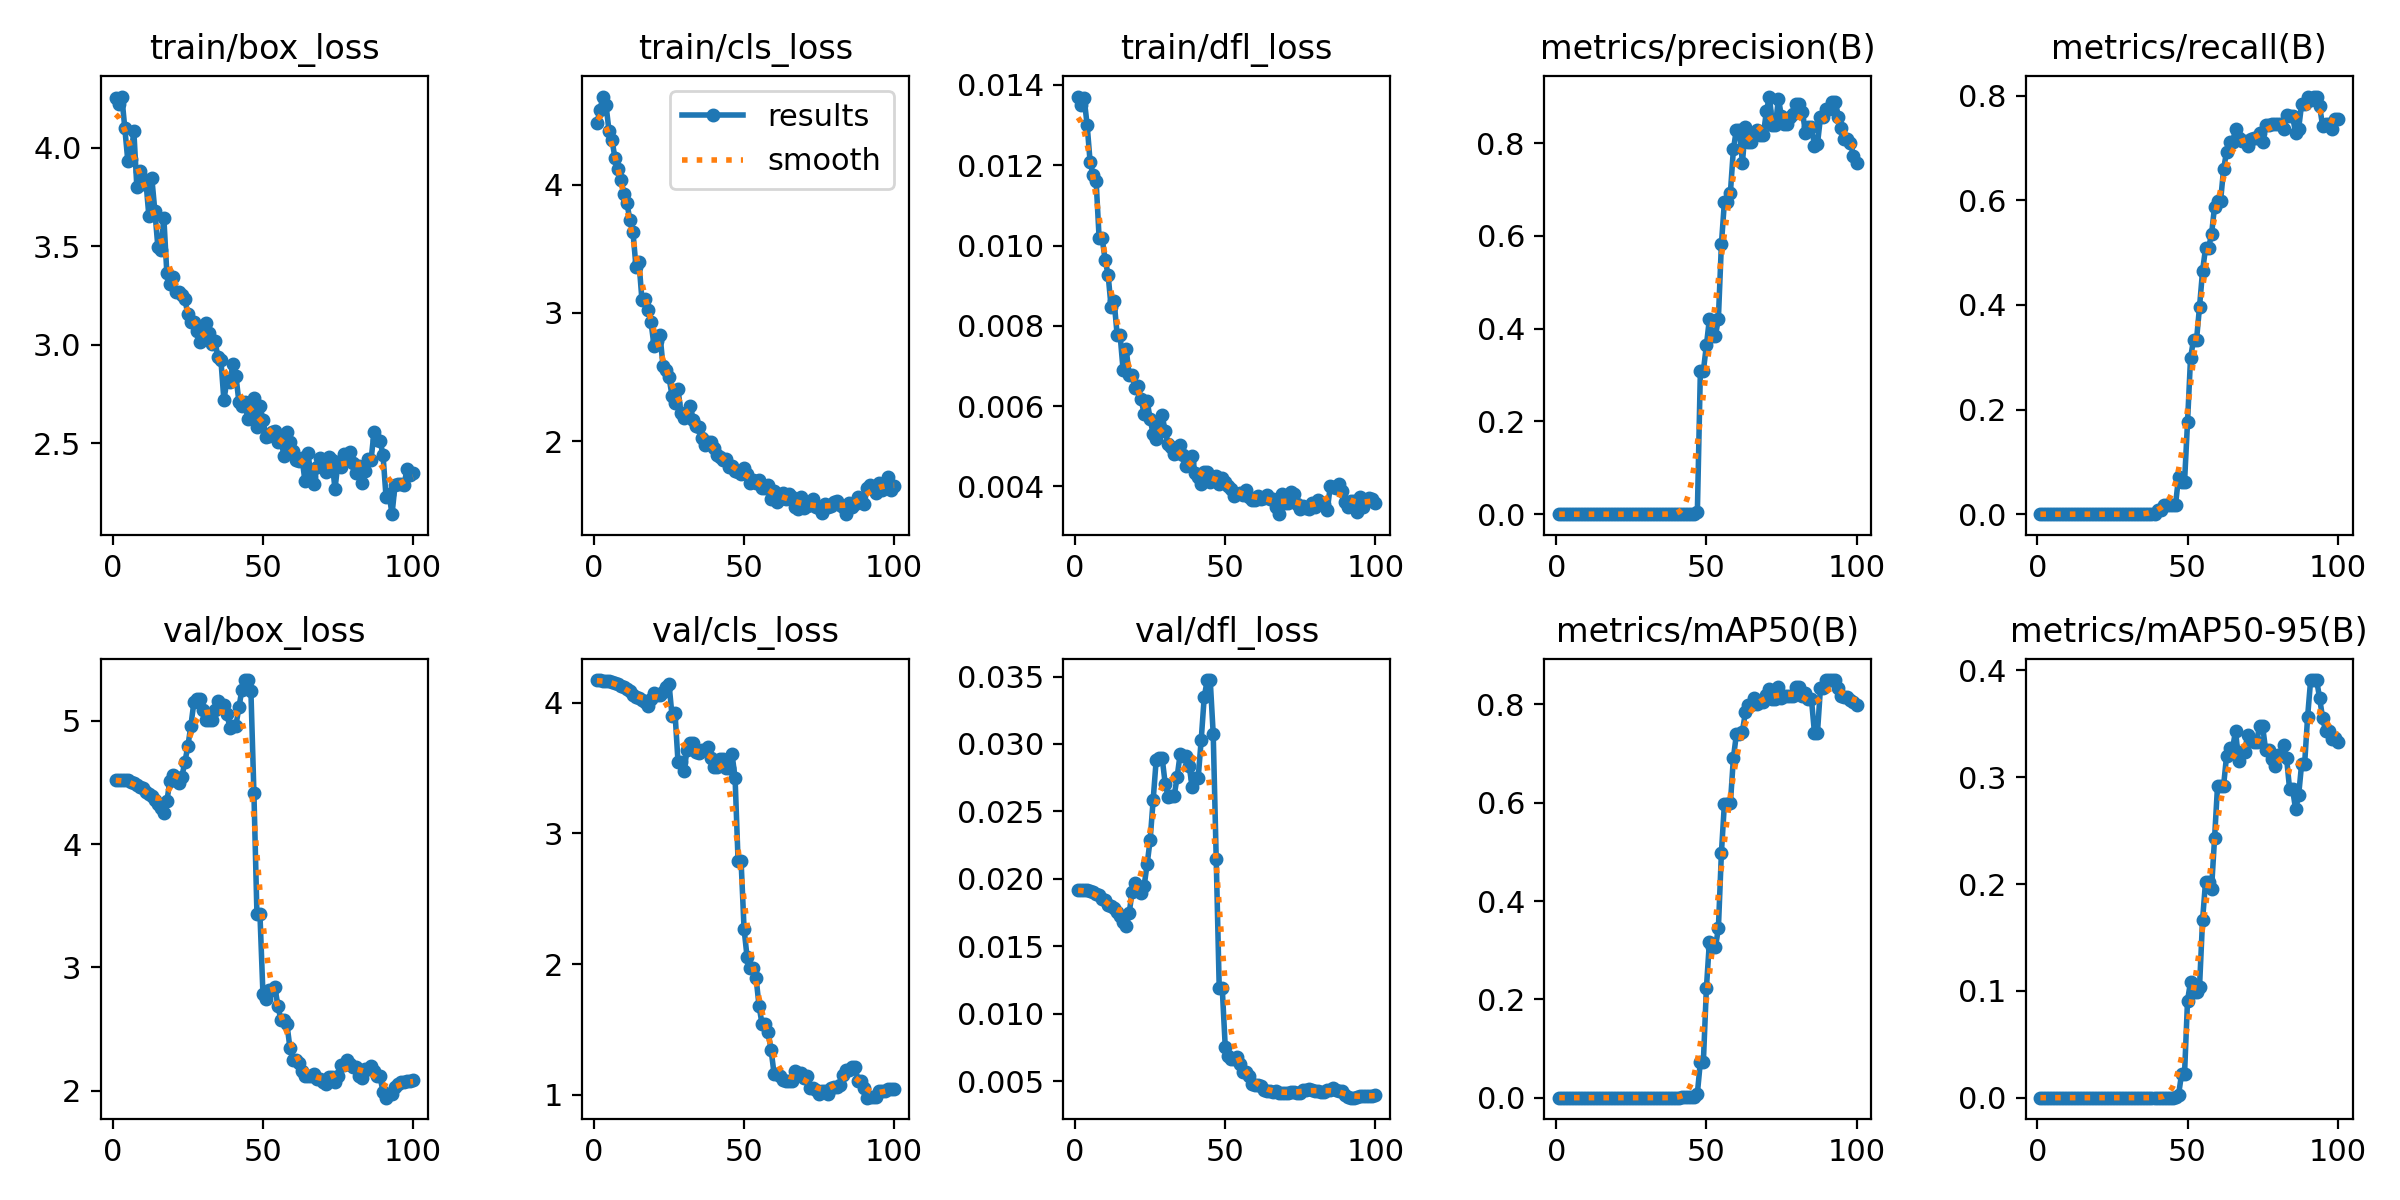

In [8]:
Image (filename=f"/content/runs/detect/train/results.png", width=600)

In [ ]:
# Test the trained model

In [ ]:
# Upload the input video

In [10]:
! cd

C:\Courses\2026\Udemy\Computer-Vision-Systems\runs


In [3]:
# Load the best weights model.
model = YOLO ("A100/best.pt") # yolo26x
# model = YOLO ("yolo11s.pt") # "yolo26s.pt" 

In [4]:
# Setup annotation utilities
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator() 

In [5]:
# Setup input and output videos.
input_video_path  = "potholes.mp4"
output_video_path = "output_local_a100_1.mp4"

cap = cv2.VideoCapture (input_video_path)

frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

print(f"total_frames = {total_frames}")
print(f"fps = {fps}")
print(f"frame width = {frame_width}")
print(f"frame height = {frame_height}")

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
# fps = 1  # Slow down the output video for easier analysis, if needed.
writer = cv2.VideoWriter(output_video_path, fourcc, fps, (frame_width, frame_height))


total_frames = 351
fps = 30
frame width = 1920
frame height = 1080


In [6]:
# Loop over the video frames
counter = 0 # frame counter

while cap.isOpened():
    start = datetime.datetime.now()
    ret, frame = cap.read()
    if not ret: break
    counter += 1

    results = model (frame, verbose=False)[0]

    # Annotate a copy of the original frame
    annotated_frame = frame.copy() 

    # Process the results
    # boxes = results.boxes           # Boxes object for bbox outputs
    # print("boxes = ", boxes.xyxy)   # Print coordinates [xmin, ymin, xmax, ymax]
    # print("conf = ", boxes.conf)    # Print confidence scores
    # print("class = ", boxes.cls)    # Print class IDs
    # break

    detections = sv.Detections.from_ultralytics(results)
    # print("d1 = ", detections)
    detections = detections.with_nms() # Apply NMS (do NOT do this for YOLO26)
    # print("d2 = ", detections)
    annotated_frame = box_annotator.annotate(scene=annotated_frame, detections=detections)
    annotated_frame = label_annotator.annotate(scene=annotated_frame, detections=detections)
    writer.write(annotated_frame)
    end = datetime.datetime.now()
    print(f"Time to process frame {counter}: {(end - start).total_seconds() * 1000:.0f} miliseconds")

cap.release()
writer.release() 


Time to process frame 1: 2636 miliseconds
Time to process frame 2: 1814 miliseconds
Time to process frame 3: 1792 miliseconds
Time to process frame 4: 2042 miliseconds
Time to process frame 5: 2970 miliseconds
Time to process frame 6: 2415 miliseconds
Time to process frame 7: 1970 miliseconds
Time to process frame 8: 1756 miliseconds
Time to process frame 9: 1763 miliseconds
Time to process frame 10: 1745 miliseconds
Time to process frame 11: 1747 miliseconds
Time to process frame 12: 1745 miliseconds
Time to process frame 13: 1735 miliseconds
Time to process frame 14: 1742 miliseconds
Time to process frame 15: 1710 miliseconds
Time to process frame 16: 1770 miliseconds
Time to process frame 17: 1893 miliseconds
Time to process frame 18: 1775 miliseconds
Time to process frame 19: 1719 miliseconds
Time to process frame 20: 1711 miliseconds
Time to process frame 21: 1755 miliseconds
Time to process frame 22: 1750 miliseconds
Time to process frame 23: 1737 miliseconds
Time to process fram